# Delta expression comparison between cell types: HEK cells and Ramos B cells

This notebook calculates the change in expression between a mature Influenza bnAb (CH65) and its germline sequence (UCA860) for HEK cells and Ramos B cells

There are two biological replicates per antibody and cell type (with ~10,000 cells per replicate)

Delta expression comparisons are made per experiment and then the deltas are averaged across experiments for plotting (see Methods in Tharp et al, 2026 for detailed rationale)

**Workflow:**
1. For each row in the run-list, load the single flow file (directory + row + well)
2. Auto-detect the expression (blue) channel column for that file
3. Compute geometric mean log10 fluorescence across all cells expressing the antibody in that file
4. Calculate Δ (geometric) mean expression = CH65 − UCA860 per biological replicate
5. Summarise and plot (mean ± SEM across biological replicates)

## Import Libraries

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import re

## Load Run List

In [10]:
# Load run list
run_list = pd.read_csv('run-list.csv')
print(f"Loaded {len(run_list)} runs")
print(run_list)

Loaded 8 runs
       directory row  well     shortname
0    data/HEK_r1   A     8       LP_CH65
1    data/HEK_r1   B     8     LP_UCA860
2    data/HEK_r2   A     4       LP_CH65
3    data/HEK_r2   A     9     LP_UCA860
4  data/Ramos_r1   C     8    Ramos_CH65
5  data/Ramos_r1   D     8  Ramos_UCA860
6  data/Ramos_r2   D     4    Ramos_CH65
7  data/Ramos_r2   D     7  Ramos_UCA860


In [11]:
# Load cytometry data for each run (experiment) and compute mean log10 fluorescence for each well.
def get_file(run_id):
    """
    Load the single flow cytometry CSV for a given run.
    Returns a DataFrame, or None if the file is not found.
    """
    run_row = run_list.iloc[run_id]
    well_id = '%c%02d' % (run_row['row'], int(run_row['well']))
    pattern = os.path.join(run_row['directory'], '*%s*' % well_id)
    matches = glob.glob(pattern)
    if len(matches) != 1:
        print(f"Warning: expected 1 file for '{pattern}', found {len(matches)}")
        return None
    return pd.read_csv(matches[0])


In [12]:
# Each experiment used different cytometers, so this function finds the correct column for the expression (blue) channel
def find_blue_channel(df):
    """
    Return the first column whose name matches '530_30 Blue *-A'.
    Raises ValueError if none found.
    """
    candidates = [c for c in df.columns if re.match(r'530_30 Blue \S+-A', c)]
    if not candidates:
        raise ValueError(f"No blue channel found. Columns: {list(df.columns)}")
    if len(candidates) > 1:
        print(f"Multiple blue channels found: {candidates} — using {candidates[0]}")
    return candidates[0]


In [13]:
# Process each run - compute mean log10 fluorescence for the blue channel
results = []

for i in range(len(run_list)):
    run_info = run_list.iloc[i]
    shortname = run_info['shortname']
    # Use the leaf folder name as the bio-rep label (e.g. 'HEK_r1', 'Ramos_r2')
    bio_rep = os.path.basename(run_info['directory'])

    # Parse cell type and antibody from shortname
    parts = shortname.split('_')
    if len(parts) >= 2:
        cell_prefix = parts[0]
        antibody = parts[1]
        if 'LP' in cell_prefix or 'HEK' in cell_prefix:
            cell_type = 'HEK_LP'
        elif 'Ramo' in cell_prefix:
            cell_type = 'Ramos'
        else:
            cell_type = cell_prefix
    else:
        cell_type = shortname
        antibody = 'unknown'

    print(f"\nRun {i}: {shortname}  |  cell_type={cell_type}  antibody={antibody}  bio_rep={bio_rep}")

    df = get_file(i)
    if df is None:
        continue

    try:
        blue_channel = find_blue_channel(df)
    except ValueError as e:
        print(f"  ERROR: {e}")
        continue

    blue_vals = df[blue_channel]
    blue_vals = blue_vals[blue_vals > 0]

    if len(blue_vals) == 0:
        print(f"  WARNING: no positive values in '{blue_channel}', skipping")
        continue

    mean_log10 = np.mean(np.log10(blue_vals))
    print(f"  channel={blue_channel}  n_cells={len(blue_vals)}  mean_log10={mean_log10:.4f}")

    results.append({
        'shortname':              shortname,
        'cell_type':              cell_type,
        'antibody':               antibody,
        'bio_rep':                bio_rep,
        'blue_channel':           blue_channel,
        'n_cells':                len(blue_vals),
        'mean_log10_fluorescence': mean_log10,
    })

results_df = pd.DataFrame(results)
print(f"\n{'='*60}")
print(f"Processed {len(results_df)} runs")
print(f"{'='*60}")
display(results_df)


Run 0: LP_CH65  |  cell_type=HEK_LP  antibody=CH65  bio_rep=HEK_r1
  channel=530_30 Blue B-A  n_cells=8763  mean_log10=4.2589

Run 1: LP_UCA860  |  cell_type=HEK_LP  antibody=UCA860  bio_rep=HEK_r1
  channel=530_30 Blue B-A  n_cells=8468  mean_log10=4.3569

Run 2: LP_CH65  |  cell_type=HEK_LP  antibody=CH65  bio_rep=HEK_r2
  channel=530_30 Blue C-A  n_cells=10487  mean_log10=4.5195

Run 3: LP_UCA860  |  cell_type=HEK_LP  antibody=UCA860  bio_rep=HEK_r2
  channel=530_30 Blue C-A  n_cells=8997  mean_log10=4.5857

Run 4: Ramos_CH65  |  cell_type=Ramos  antibody=CH65  bio_rep=Ramos_r1
  channel=530_30 Blue B-A  n_cells=59279  mean_log10=4.3007

Run 5: Ramos_UCA860  |  cell_type=Ramos  antibody=UCA860  bio_rep=Ramos_r1
  channel=530_30 Blue B-A  n_cells=35808  mean_log10=4.4945

Run 6: Ramos_CH65  |  cell_type=Ramos  antibody=CH65  bio_rep=Ramos_r2
  channel=530_30 Blue C-A  n_cells=9229  mean_log10=4.3918

Run 7: Ramos_UCA860  |  cell_type=Ramos  antibody=UCA860  bio_rep=Ramos_r2
  channe

,shortname,cell_type,antibody,bio_rep,blue_channel,n_cells,mean_log10_fluorescence
0,LP_CH65,HEK_LP,CH65,HEK_r1,530_30 Blue B-A,8763,4.258898
1,LP_UCA860,HEK_LP,UCA860,HEK_r1,530_30 Blue B-A,8468,4.356898
2,LP_CH65,HEK_LP,CH65,HEK_r2,530_30 Blue C-A,10487,4.519505
3,LP_UCA860,HEK_LP,UCA860,HEK_r2,530_30 Blue C-A,8997,4.585718
4,Ramos_CH65,Ramos,CH65,Ramos_r1,530_30 Blue B-A,59279,4.300661
5,Ramos_UCA860,Ramos,UCA860,Ramos_r1,530_30 Blue B-A,35808,4.494475
6,Ramos_CH65,Ramos,CH65,Ramos_r2,530_30 Blue C-A,9229,4.391762
7,Ramos_UCA860,Ramos,UCA860,Ramos_r2,530_30 Blue C-A,9245,4.531238


In [14]:
# Compute Δ log10 fluorescence (CH65 - UCA860) for each bio-rep, then summarize across bio-reps for each cell type.
delta_rows = []

for (cell_type, bio_rep), grp in results_df.groupby(['cell_type', 'bio_rep']):
    ch65_rows   = grp[grp['antibody'] == 'CH65']
    uca860_rows = grp[grp['antibody'] == 'UCA860']

    if ch65_rows.empty or uca860_rows.empty:
        print(f"Warning: missing antibody data for {cell_type} / {bio_rep}")
        continue

    ch65_val   = ch65_rows['mean_log10_fluorescence'].values[0]
    uca860_val = uca860_rows['mean_log10_fluorescence'].values[0]
    delta      = ch65_val - uca860_val

    delta_rows.append({
        'cell_type':   cell_type,
        'bio_rep':     bio_rep,
        'ch65_expr':   ch65_val,
        'uca860_expr': uca860_val,
        'delta':       delta,
    })

delta_df = pd.DataFrame(delta_rows)
print("Delta expression per biological replicate:")
display(delta_df)

# Summary: mean ± SEM across bio reps for each cell type
summary = delta_df.groupby('cell_type')['delta'].agg(['mean', 'sem', 'count'])
summary.columns = ['mean_delta', 'sem_delta', 'n_bio_reps']
print("\nSummary across biological replicates:")
display(summary)

Delta expression per biological replicate:


,cell_type,bio_rep,ch65_expr,uca860_expr,delta
0,HEK_LP,HEK_r1,4.258898,4.356898,-0.098001
1,HEK_LP,HEK_r2,4.519505,4.585718,-0.066213
2,Ramos,Ramos_r1,4.300661,4.494475,-0.193814
3,Ramos,Ramos_r2,4.391762,4.531238,-0.139476



Summary across biological replicates:


,mean_delta,sem_delta,n_bio_reps
cell_type,,,
HEK_LP,-0.082107,0.015894,2
Ramos,-0.166645,0.027169,2


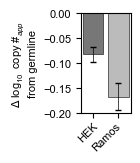


Figure saved as: S_Figure_2a.png


In [15]:
# Plot average deltas with SEM error bars and save results
plt.rcParams.update({
    'font.family': 'Arial',
    'font.sans-serif': ['Arial'],
    'mathtext.fontset': 'custom',
    'mathtext.rm': 'Arial',
    'mathtext.it': 'Arial:italic',
    'mathtext.bf': 'Arial:bold',
})

summary_plot = summary.reset_index().sort_values(
    'cell_type', key=lambda x: x.map({'HEK_LP': 0, 'Ramos': 1})
)

# Define plot area and margins in inches
plot_width    = 0.5
plot_height   = 1
left_margin   = 0.55
right_margin  = 0.15
top_margin    = 0.15
bottom_margin = 0.4

fig_width  = plot_width  + left_margin  + right_margin
fig_height = plot_height + top_margin   + bottom_margin

left   = left_margin   / fig_width
right  = 1 - right_margin  / fig_width
top    = 1 - top_margin    / fig_height
bottom = bottom_margin / fig_height

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
fig.subplots_adjust(left=left, right=right, top=top, bottom=bottom)

colors = ['#555555', '#AAAAAA']

ax.bar(
    summary_plot['cell_type'],
    summary_plot['mean_delta'],
    yerr=summary_plot['sem_delta'],
    color=colors[:len(summary_plot)],
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    capsize=2,
    error_kw={'linewidth': 0.5, 'ecolor': 'black'}
)

ax.set_ylabel('Δ $\\log_{10}$ copy #$_{\mathit{app}}$\nfrom germline', fontsize=8)
ax.set_xticks(range(len(summary_plot)))
ax.set_xticklabels([])
ax.set_ylim(-0.2, 0)
ax.set_yticks([-0.2, -0.15, -0.10, -0.05, 0])
ax.tick_params(axis='y', labelsize=8)
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Manually place x-axis labels
bar_positions_fig = [
    left + (right - left) * (i - 0.25) / len(summary_plot)
    for i in range(len(summary_plot))
]
label_y = bottom - 0.05
for i, label in enumerate(['HEK', 'Ramos']):
    offset = 0.02 if i == 0 else -0.0725
    fig.text(bar_positions_fig[i] + offset, label_y, label,
             fontsize=8, rotation=45, ha='left', va='top',
             transform=fig.transFigure)

plt.savefig('S_Figure_2a.png', dpi=2000, bbox_inches='tight', transparent=True)
plt.show()
print("\nFigure saved as: S_Figure_2a.png")

## Summary Statistics

In [16]:
print('='*60)
print('SUMMARY STATISTICS')
print('='*60)
print('\nPer-biological-replicate deltas (CH65 − UCA860):')
display(delta_df)

print('\nAggregated across biological replicates:')
for _, row in summary.reset_index().iterrows():
    ct     = row['cell_type']
    mean_d = row['mean_delta']
    sem_d  = row['sem_delta']
    n      = int(row['n_bio_reps'])
    print(f'\n{ct} (n={n} bio reps):')
    print(f'  Mean delta (CH65 - UCA860): {mean_d:.4f} ± {sem_d:.4f} SEM')
    print(f'  Fold change: {10**mean_d:.3f}x')
    if mean_d > 0:
        print(f'  → CH65 shows {10**mean_d:.2f}x higher expression than UCA860')
    else:
        print(f'  → UCA860 shows {10**(-mean_d):.2f}x higher expression than CH65')
print('='*60)

SUMMARY STATISTICS

Per-biological-replicate deltas (CH65 − UCA860):


,cell_type,bio_rep,ch65_expr,uca860_expr,delta
0,HEK_LP,HEK_r1,4.258898,4.356898,-0.098001
1,HEK_LP,HEK_r2,4.519505,4.585718,-0.066213
2,Ramos,Ramos_r1,4.300661,4.494475,-0.193814
3,Ramos,Ramos_r2,4.391762,4.531238,-0.139476



Aggregated across biological replicates:

HEK_LP (n=2 bio reps):
  Mean delta (CH65 - UCA860): -0.0821 ± 0.0159 SEM
  Fold change: 0.828x
  → UCA860 shows 1.21x higher expression than CH65

Ramos (n=2 bio reps):
  Mean delta (CH65 - UCA860): -0.1666 ± 0.0272 SEM
  Fold change: 0.681x
  → UCA860 shows 1.47x higher expression than CH65
